In [76]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

print("python-control lib version: ", ctrl.__version__)

python-control lib version:  0.10.1


In [87]:
A = [ [-3] ];
B = [ [ 1] ];
C = [ [ 1] ];

In [88]:
AI=np.hstack(
    (np.zeros((2,1)),
    np.vstack((C,A)))
    )

BI=np.vstack([np.zeros([1,1]),B])


In [89]:
m_ctrb = ctrl.ctrb(AI,BI)
rango_ctrb = np.linalg.matrix_rank(m_ctrb)

print("Rango la matriz de controlabilidad:",rango_ctrb)


Rango la matriz de controlabilidad: 2


In [91]:
p1 = -5

p_obj1= [p1, p1]

K1 = ctrl.acker(AI,BI,p_obj1);
K1


array([[25.,  7.]])

In [93]:
At=AI-BI*K1

Bt=[[-1],
    [ 0]]

Ct=np.hstack([np.zeros([2,1]),np.vstack([np.zeros([1,1]),C])])
Dt=np.zeros([2,1])

sys_cl1 = ctrl.ss(At,Bt,Ct,Dt)

sys_cl1.poles()

array([-5.00000004+0.j, -4.99999996+0.j])

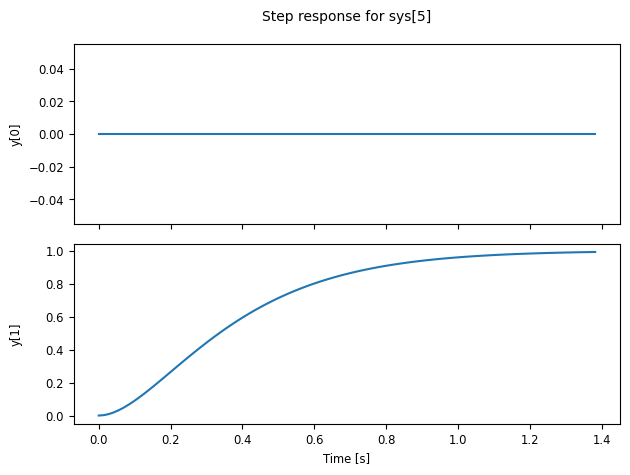

In [82]:
rta_escalon=ctrl.step_response(sys_cl1)
rta_escalon.plot()

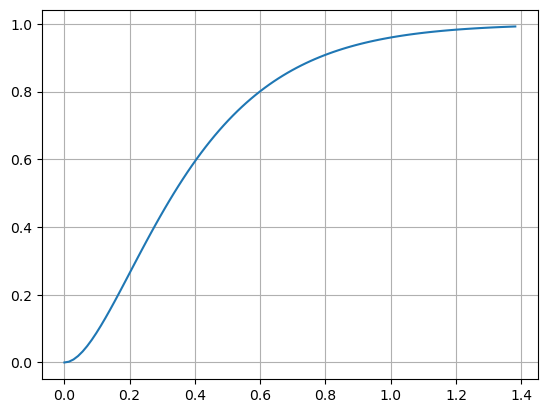

In [83]:
plt.plot(t,y[1][0])
plt.grid()
plt.show()

In [84]:
#2 veces respecto a los polos p_obj
op1 = -10

In [85]:
L = ctrl.place(np.matrix(A).T,np.matrix(C).T,np.matrix([op1])).T
L

array([[7.]])

In [86]:
At = np.vstack((np.hstack((A-B@K2,B@K2)),
               np.hstack((np.zeros(np.shape(A)),A-L*C))))

Bt = np.vstack((np.matrix(B)*Nbar,
       np.zeros(np.shape(B))))

Ct = np.hstack((C,np.zeros(np.shape(C))))

NameError: name 'K2' is not defined

Para ver la respuesta del sistema ante condiciones iniciales no nulas, sin entrada de referencia, lo haremos con los siguientes comandos. Asumimos que el observador comienza con condiciones iniciales nulas, por lo que el error de estimación inicial es el vector de estados inicial, $\tilde{\mathbf{x}} = \mathbf{x}$.

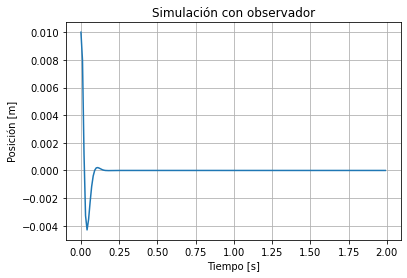

In [23]:
sys_tot = ctrl.ss(At,Bt,Ct,0);

t_tot,y_tot,x_tot =ctrl.forced_response(sys_tot,U=np.zeros(t.size),T=t,X0=np.hstack((x0,x0)),return_x=True)

plt.plot(t_tot,y_tot)
plt.grid()
plt.title('Simulación con observador')
plt.xlabel('Tiempo [s]')
plt.ylabel('Posición [m]');

Si comparamos con los resultados obtenidos antes, podemos notar una degradación en la performance del sistema, esto se relaciona con las condiciones iniciales del estimador y su dinámica; puede ser resuelto ajustando el estimador:

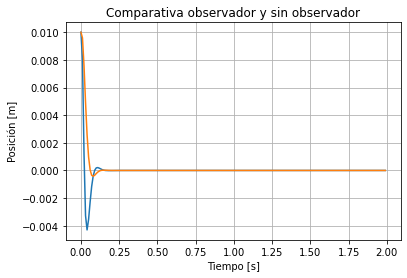

In [24]:
plt.plot(t_tot,y_tot,t2,y2)
plt.grid()
plt.title('Comparativa observador y sin observador')
plt.xlabel('Tiempo [s]')
plt.ylabel('Posición [m]');

La evolución de todos los estados se ve en la gráfica de abajo. A partir de $\mathbf{x}$ y $\tilde{\mathbf{x}}$; para obtener $\hat{\mathbf{x}}$, necesitamos calcular $\mathbf{x} - \tilde{\mathbf{x}}$.

In [25]:
t = np.arange(0,.1,1E-6);
x0 = [0.01,0.5,-5];

t_tot2,y_tot2,x_tot2 =ctrl.forced_response(sys_tot,U=np.zeros(t.size),T=t,X0=np.hstack((x0,x0)),return_x=True)

x = x_tot2[0:3,:]
e_est = x_tot2[3:,:]
x_est = x - e_est;

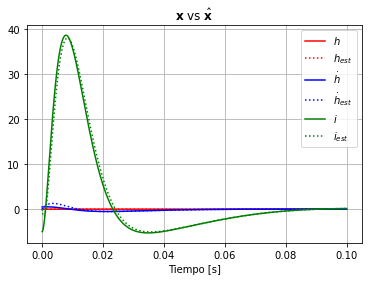

In [26]:
plt.plot(t,x[0,:],
         '-r',t,x_est[0,:],':r',t,x[1,:],
         '-b',t,x_est[1,:],':b',t,x[2,:],
         '-g',t,x_est[2,:],':g')

plt.title(r'$\mathbf{x}$ vs $\hat{\mathbf{x}}$')
plt.legend(['$h$','$h_{est}$','$\dot h$','$\dot h_{est}$','$i$','$i_{est}$'])
plt.grid()
plt.xlabel('Tiempo [s]');

Graficamos los primeros puntos para ver mejor el instante inicial

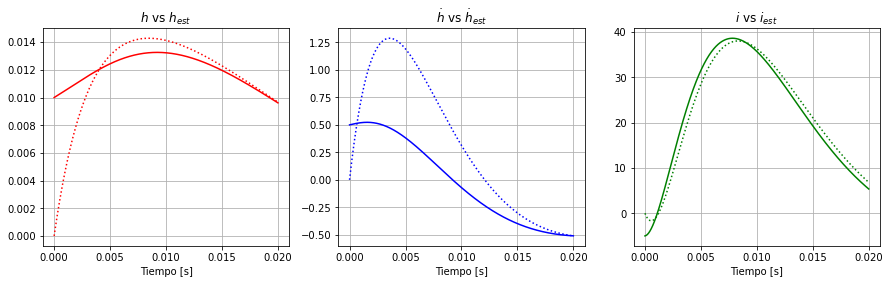

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t[0:20000],x[0,0:20000],'-r',t[0:20000],x_est[0,0:20000],':r')
axes[0].set_title('$h$ vs $h_{est}$')
axes[0].grid()
axes[0].set_xlabel('Tiempo [s]');

axes[1].plot(t[0:20000],x[1,0:20000],'-b',t[0:20000],x_est[1,0:20000],':b')
axes[1].set_title('$\dot h$ vs $\dot h_{est}$')
axes[1].grid()
axes[1].set_xlabel('Tiempo [s]');

axes[2].plot(t[0:20000],x[2,0:20000],'-g',t[0:20000],x_est[2,0:20000],':g')
axes[2].set_title('$i$ vs $i_{est}$');
axes[2].grid()
axes[2].set_xlabel('Tiempo [s]');

<a id="id7"></a>    
## Citas y Referencias:

<div class="alert alert-block alert-info">
<b></b> Por ahora dejo las citas y referencia con este formato, si encuentro algo mejor lo cambio.
</div>


___
<a id="cite1"></a>
**REF#1: Control Tutorials for Matlab & Simulink**.

title = Introduction: State-Space Methods for Controller Design.   
url = https://ctms.engin.umich.edu/CTMS/index.php?example=Introduction&section=ControlStateSpace    
note = Accessed: 2022-04-18   

___
<a id="cite2"></a>
**REF#2: Apuntes de Control Clásico y Variables de Estado**   

autor = Molina, Gonzalo  
url = https://gonmolina.github.io/CCyVE_book/sources/notebooks_sources/modulo1/linealizacion/linealizacion.html   
note = Accessed: 2022-04-18    

___ 
<a id="cite3"></a>    
**REF#3: Multivariable Feedback Control: Analysis and Design**

author = Skogestad, Sigurd and Postlethwaite, Ian   
year = 2005   
isbn = 0470011688   
publisher = John Wiley &amp; Sons, Inc.   
address = Hoboken, NJ, USA   

___

    
<!--bibtex
@misc{ctms,
  title = {{Control Tutorials for Matlab & Simulink} Introduction: State-Space Methods for Controller Design},
  howpublished = {\url{https://ctms.engin.umich.edu/CTMS/index.php?example=Introduction&section=ControlStateSpace}},
  note = {Accessed: 2022-04-18}
  

@misc{CCyVE,
  title = {{Apuntes de Control Clásico y Variables de Estado} Linealización},
  author = {Molina, Gonzalo},
  howpublished = \url{https://gonmolina.github.io/CCyVE_book/sources/notebooks_sources/modulo1/linealizacion/linealizacion.html}},
  note = {Accessed: 2022-04-18}
  

 @book{10.5555/1121635,
    author = {Skogestad, Sigurd and Postlethwaite, Ian},
    title = {Multivariable Feedback Control: Analysis and Design},
    year = {2005},
    isbn = {0470011688},
    publisher = {John Wiley &amp; Sons, Inc.},
    address = {Hoboken, NJ, USA}
    }
 -->

<a rel="license" href="http://creativecommons.org/licenses/by/4.0/"><img alt="Licencia Creative Commons" style="border-width:0" src="https://i.creativecommons.org/l/by/4.0/88x31.png" /></a><br />Esta obra está bajo una <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">Licencia Creative Commons Atribución 4.0 Internacional</a>.